In [143]:
#import dataset

import pandas as pd

df = pd.read_csv(r"/home/lero/idrive/cmac/DDMAP/Stability studies/Stability_dataset_August_update.csv", na_values='nan')
df['days stable'] = df['Average days stable']/24
df


,Unnamed: 0.1,Well_Index,Timestamp,Class,Duplicate,Timestamp (duplicate),Class (duplicate),Average days stable,API,Polymer,...,fr_term_acetylene_y,fr_tetrazole_y,fr_thiazole_y,fr_thiocyan_y,fr_thiophene_y,fr_unbrch_alkane_y,fr_urea_y,Temperature,Humidity,days stable
0,482.0,2,2160.000000,NaN,50,2160.000000,NaN,2160.000000,Acetaminophen,Soluplus,...,0.0,0.0,0.0,0.0,0.0,40.000000,0.0,NaN,NaN,90.000000
1,483.0,3,2160.000000,NaN,51,2160.000000,NaN,2160.000000,Acetaminophen,Soluplus,...,0.0,0.0,0.0,0.0,0.0,40.000000,0.0,NaN,NaN,90.000000
2,484.0,4,2160.000000,NaN,52,2160.000000,NaN,2160.000000,Acetaminophen,Soluplus,...,0.0,0.0,0.0,0.0,0.0,40.000000,0.0,NaN,NaN,90.000000
3,485.0,5,2160.000000,NaN,53,2160.000000,NaN,2160.000000,Acetaminophen,Soluplus,...,0.0,0.0,0.0,0.0,0.0,40.000000,0.0,NaN,NaN,90.000000
4,486.0,6,2160.000000,NaN,54,2160.000000,NaN,2160.000000,Acetaminophen,Soluplus,...,0.0,0.0,0.0,0.0,0.0,40.000000,0.0,NaN,NaN,90.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4603,3774.0,30,31.669722,Crystal,78,36.540833,Crystal,34.105278,Tinidazole,Affinisol,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,1.421053
4604,3777.0,33,65.763056,Crystal,81,0.000000,Crystal,32.881528,Tinidazole,HPMCAS,...,0.0,0.0,0.0,0.0,0.0,0.866667,0.0,NaN,NaN,1.370064
4605,3771.0,27,19.490556,Crystal,75,41.409722,Crystal,30.450139,Tinidazole,Affinisol,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,1.268756
4606,4712.0,8,0.000000,Crystal,56,4.876944,Crystal,2.438472,Tinidazole,PVP_K30,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,NaN,0.101603


In [142]:
new_df=pd.DataFrame({
    'API':df['API'],
    'Polymer':df['Polymer'],
    'Average hours stable':df['Average days stable'], 
    'stable less than 1 week':(df['Average days stable']<24).astype(int),
    'total_cryst_systems':(df['Average days stable']<2160).astype(int)
})

total = len(df)

less_than_a_week_count = new_df['stable less than 1 week'].sum()
total_cryst = new_df['total_cryst_systems'].sum()

print(less_than_a_week_count)

less_than_a_week_percent = (less_than_a_week_count/total_cryst)*100

print(less_than_a_week_percent)

1356
63.18732525629077


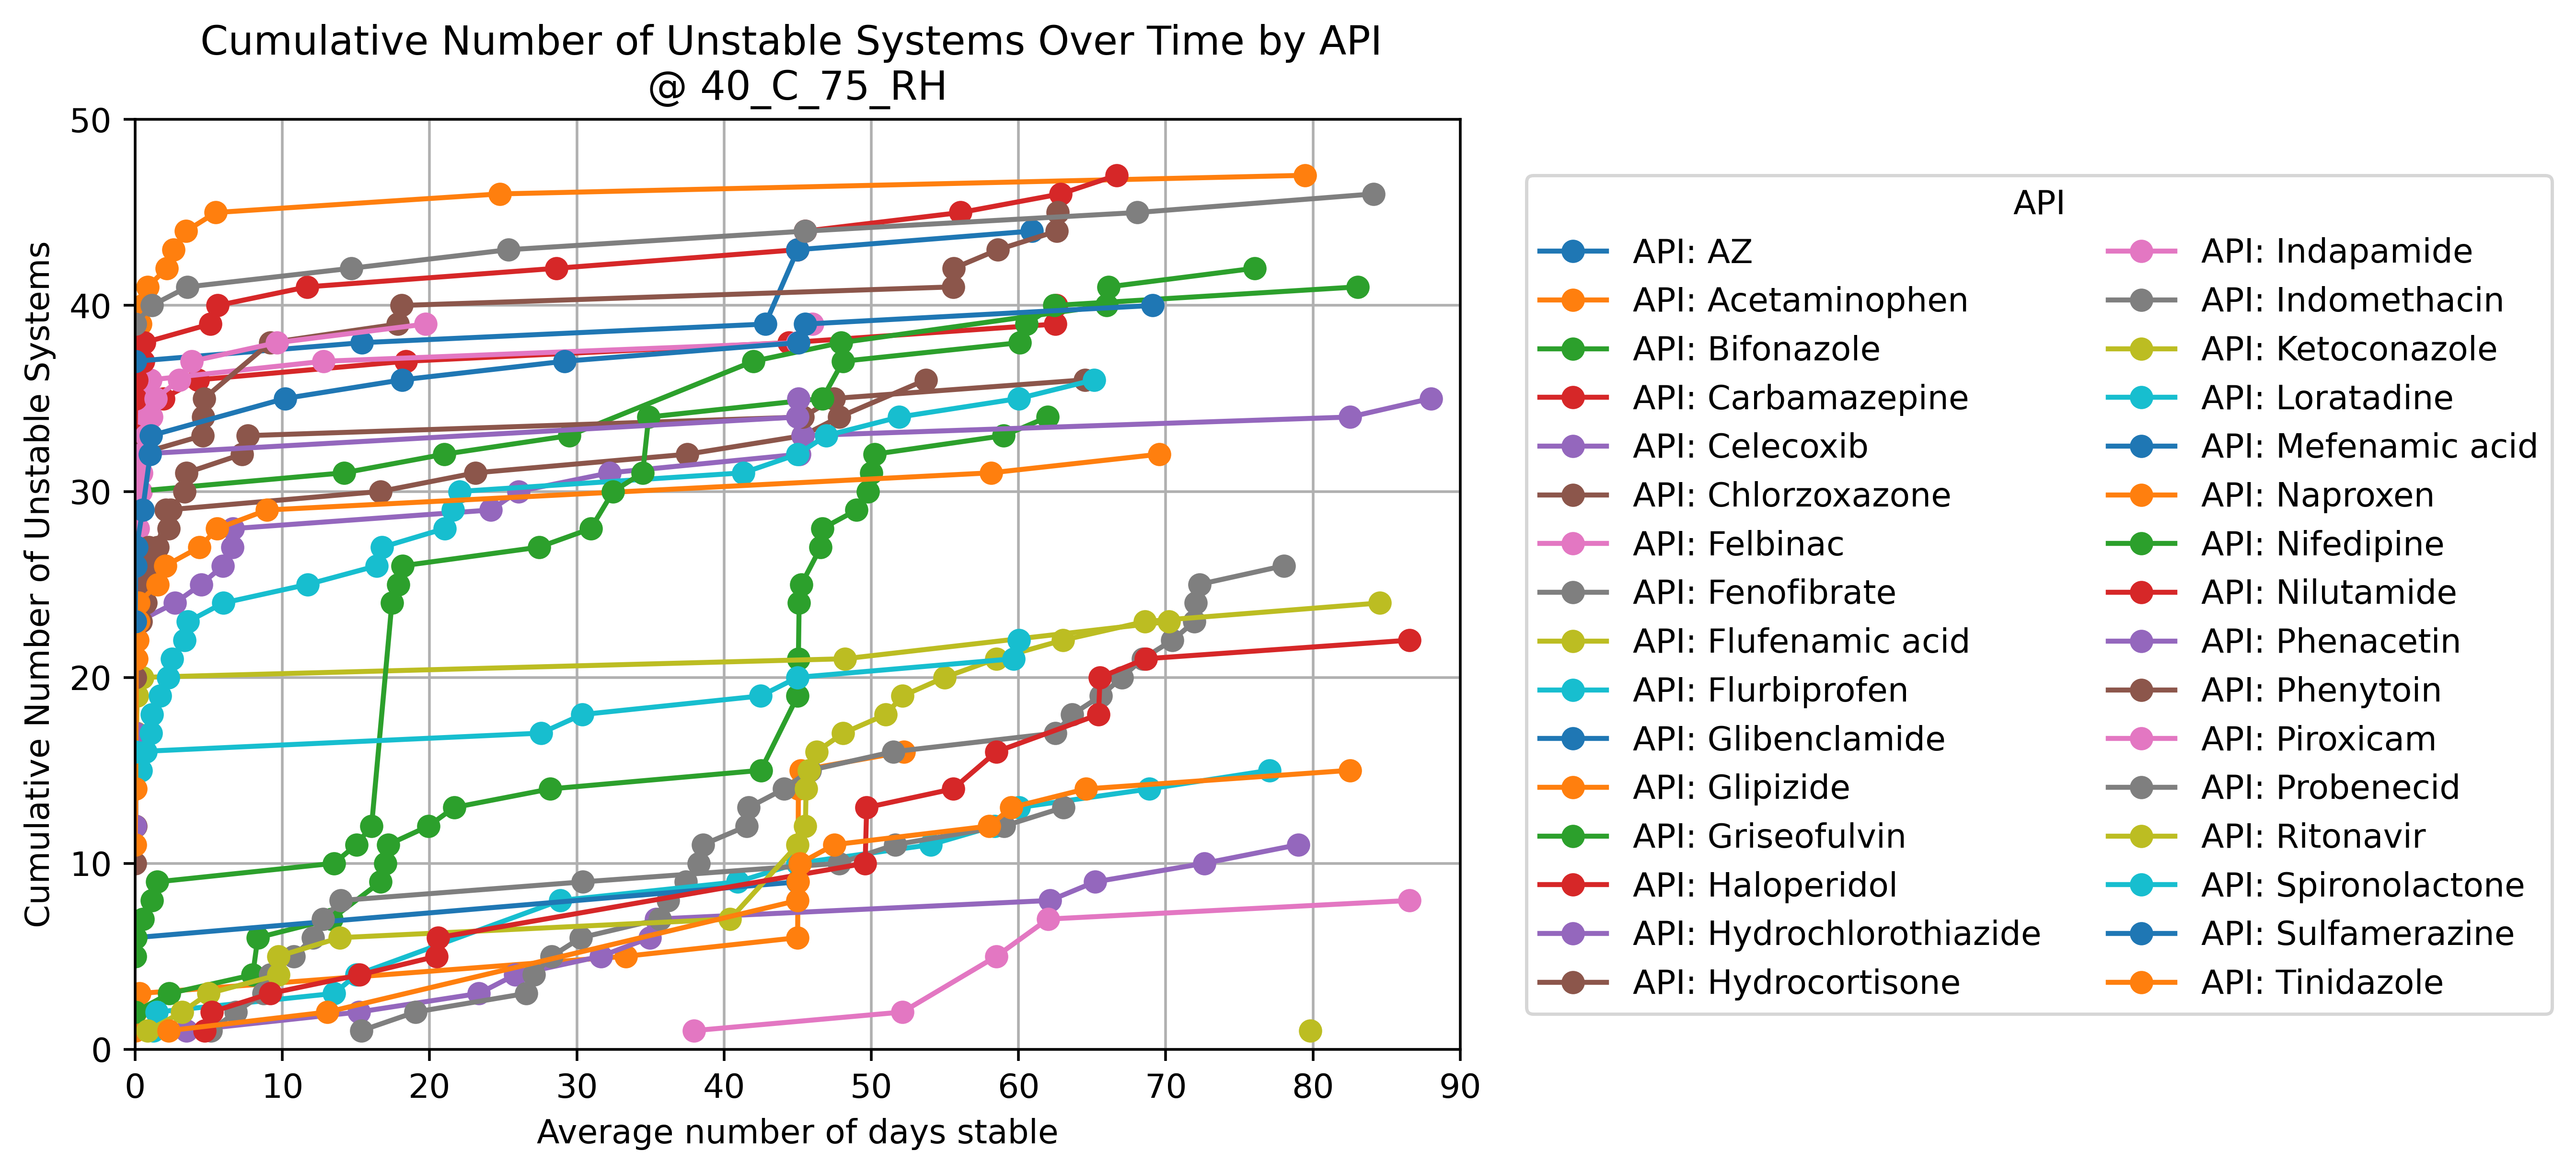

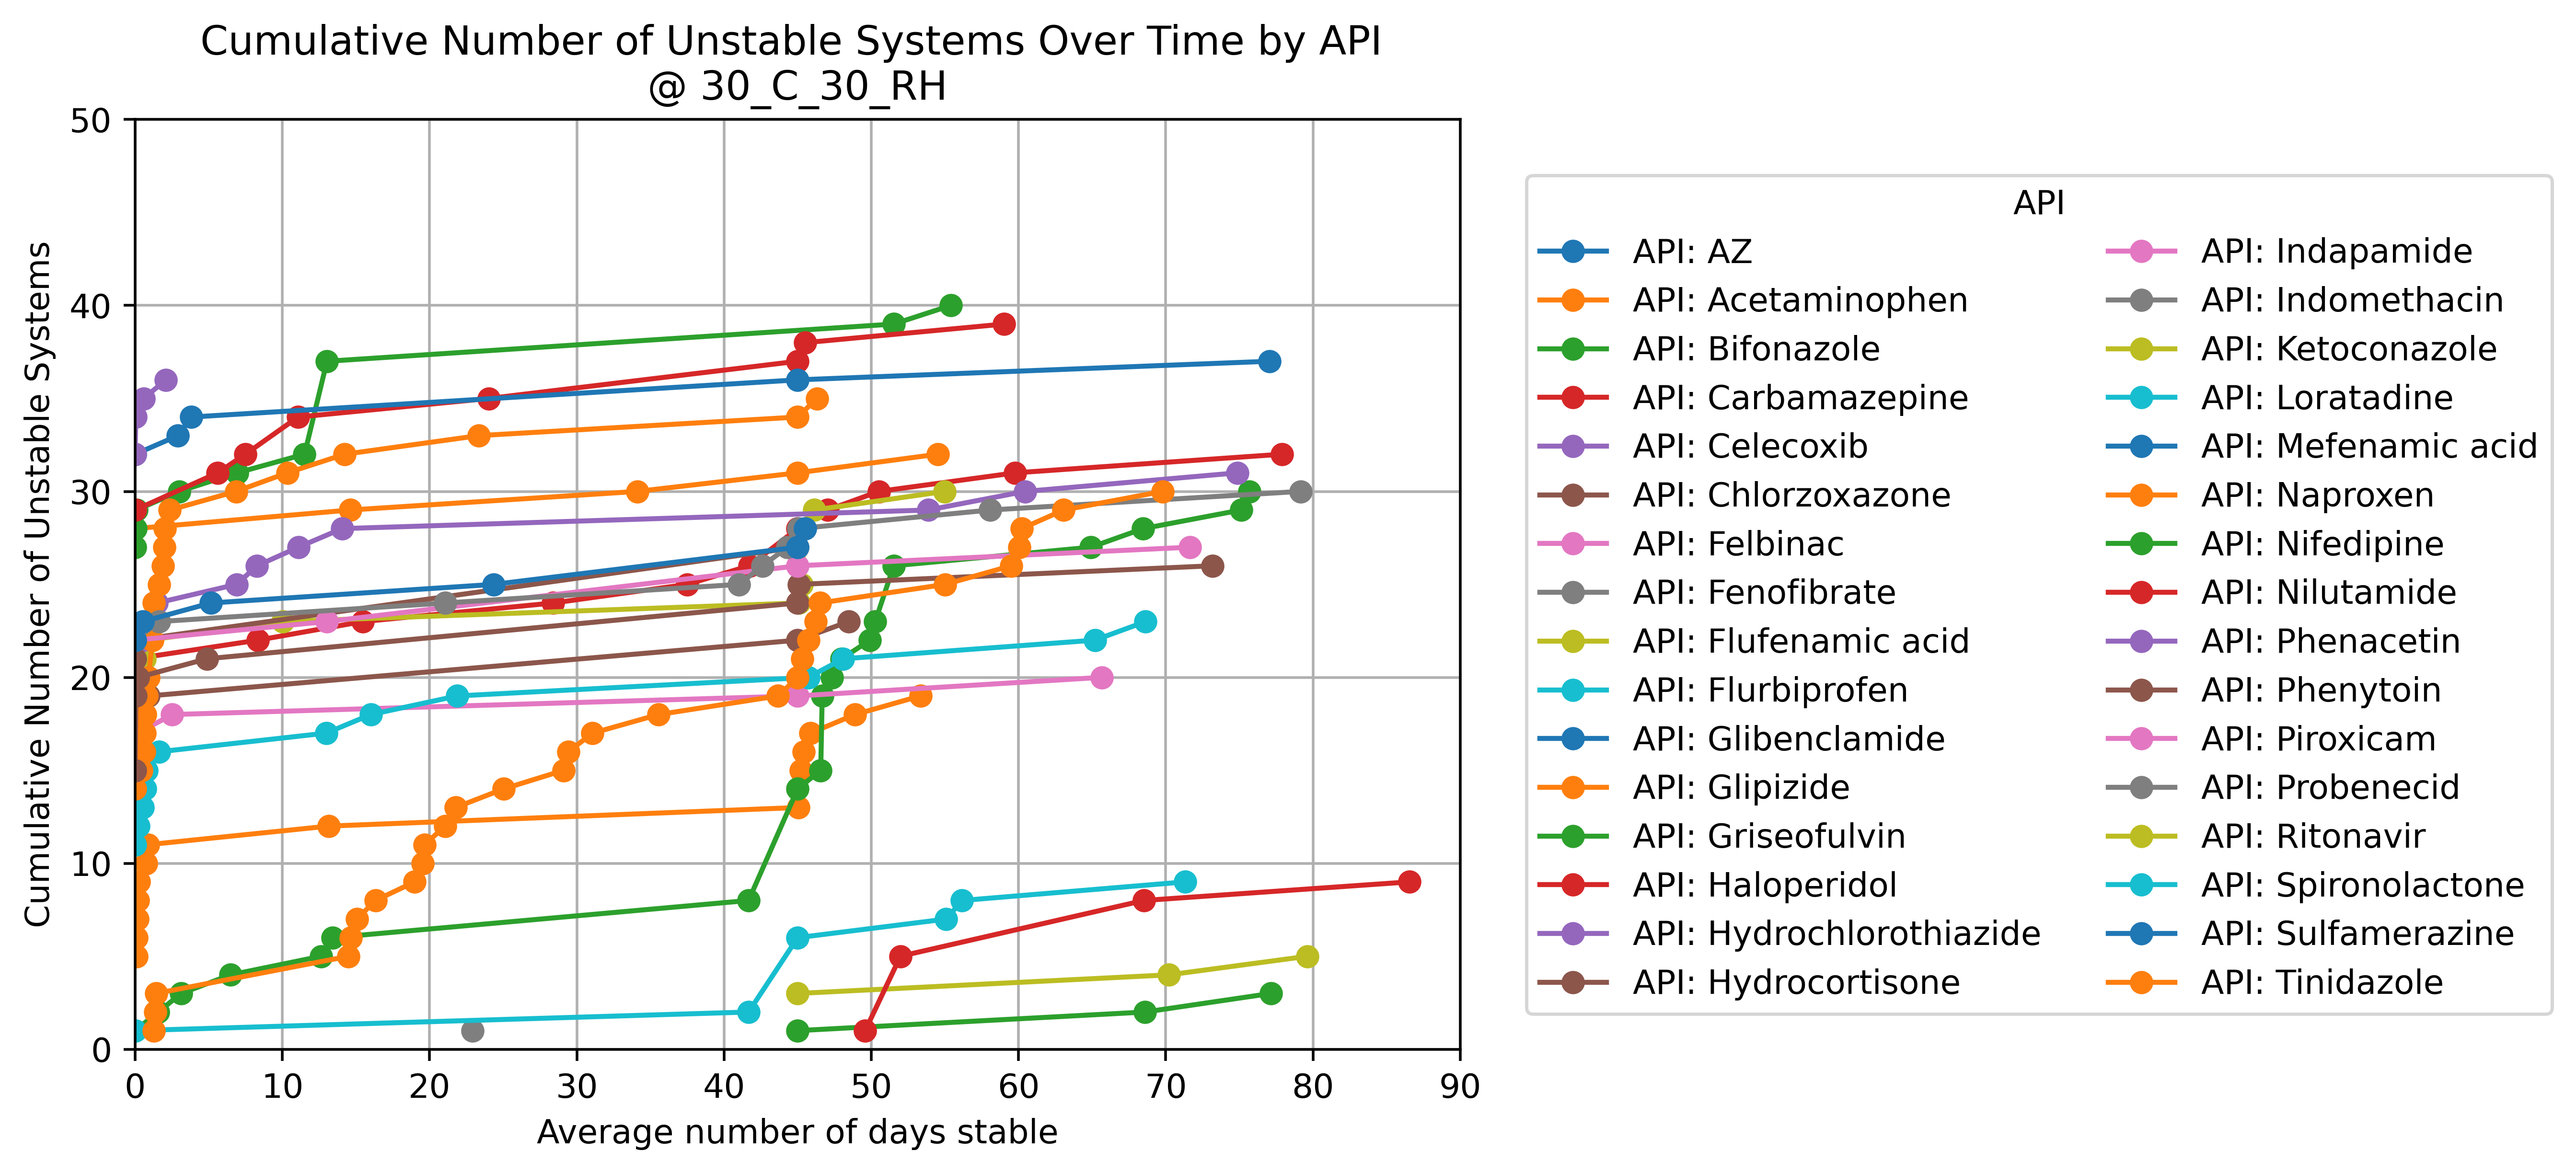

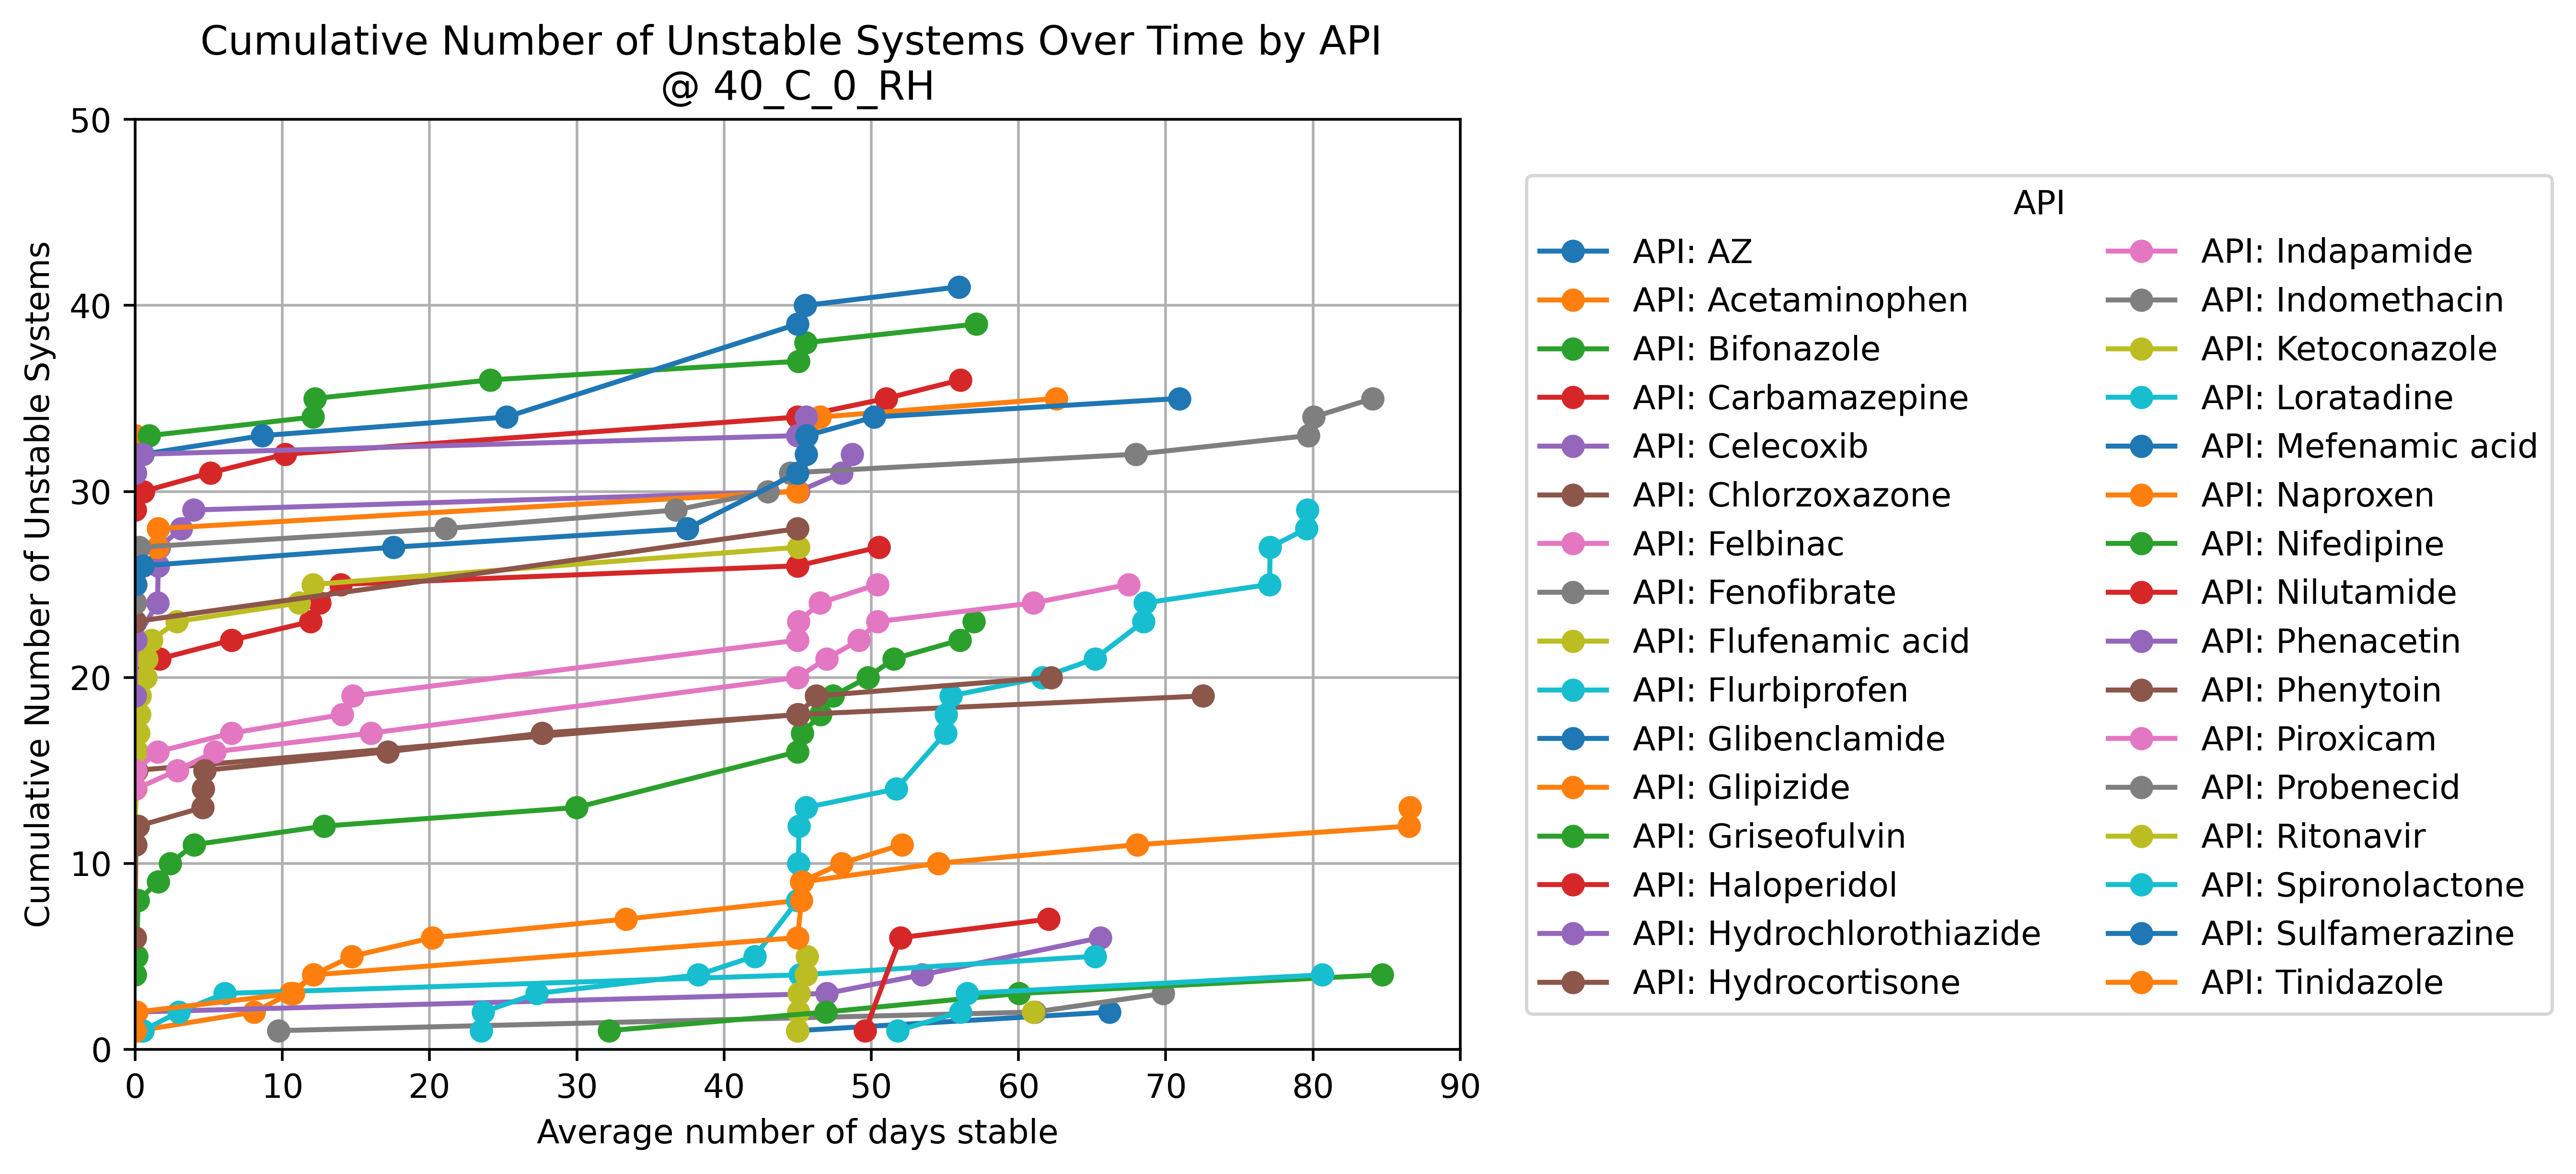

In [61]:
#Cumulative line plot
import matplotlib.pyplot as plt
import numpy as np
import os

save_dir = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Plots'

# Define a threshold for instability
stability_threshold = 90

# Determine unstable systems
df['Unstable'] = df['days stable'] < stability_threshold

conditions = df['condition'].unique()

for condition in conditions:
    
    condition_data = df[df['condition'] == condition]
    
    grouped_data = condition_data.groupby('API')
    
    plt.figure(figsize=(11, 5), dpi=500)
    # Group by 'Average days stable' and count unstable systems
    for api, group in grouped_data:
        unstable_counts = group[group['Unstable']].groupby('days stable')['Unstable'].count().cumsum()
    
    # Plot the data for each API
        plt.plot(unstable_counts.index, unstable_counts.values, marker='o', linestyle='-', label=f'API: {api}')

    # Add labels and title
    plt.xlabel('Average number of days stable')
    plt.xlim(0, 90)
    plt.ylim(0, 50)
    plt.xticks(np.arange(0, 91, step = 10))
    plt.ylabel('Cumulative Number of Unstable Systems')
    plt.title(f'Cumulative Number of Unstable Systems Over Time by API \n@ {condition}')
    plt.legend(title='API', ncol=2, bbox_to_anchor=(1.05, 0.94), loc='upper left', borderaxespad=0.)
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plot_filename = os.path.join(save_dir, f'Cumulative Number of Unstable Systems Over Time by API @ {condition}.png')
    plt.savefig(plot_filename)
    plt.show()

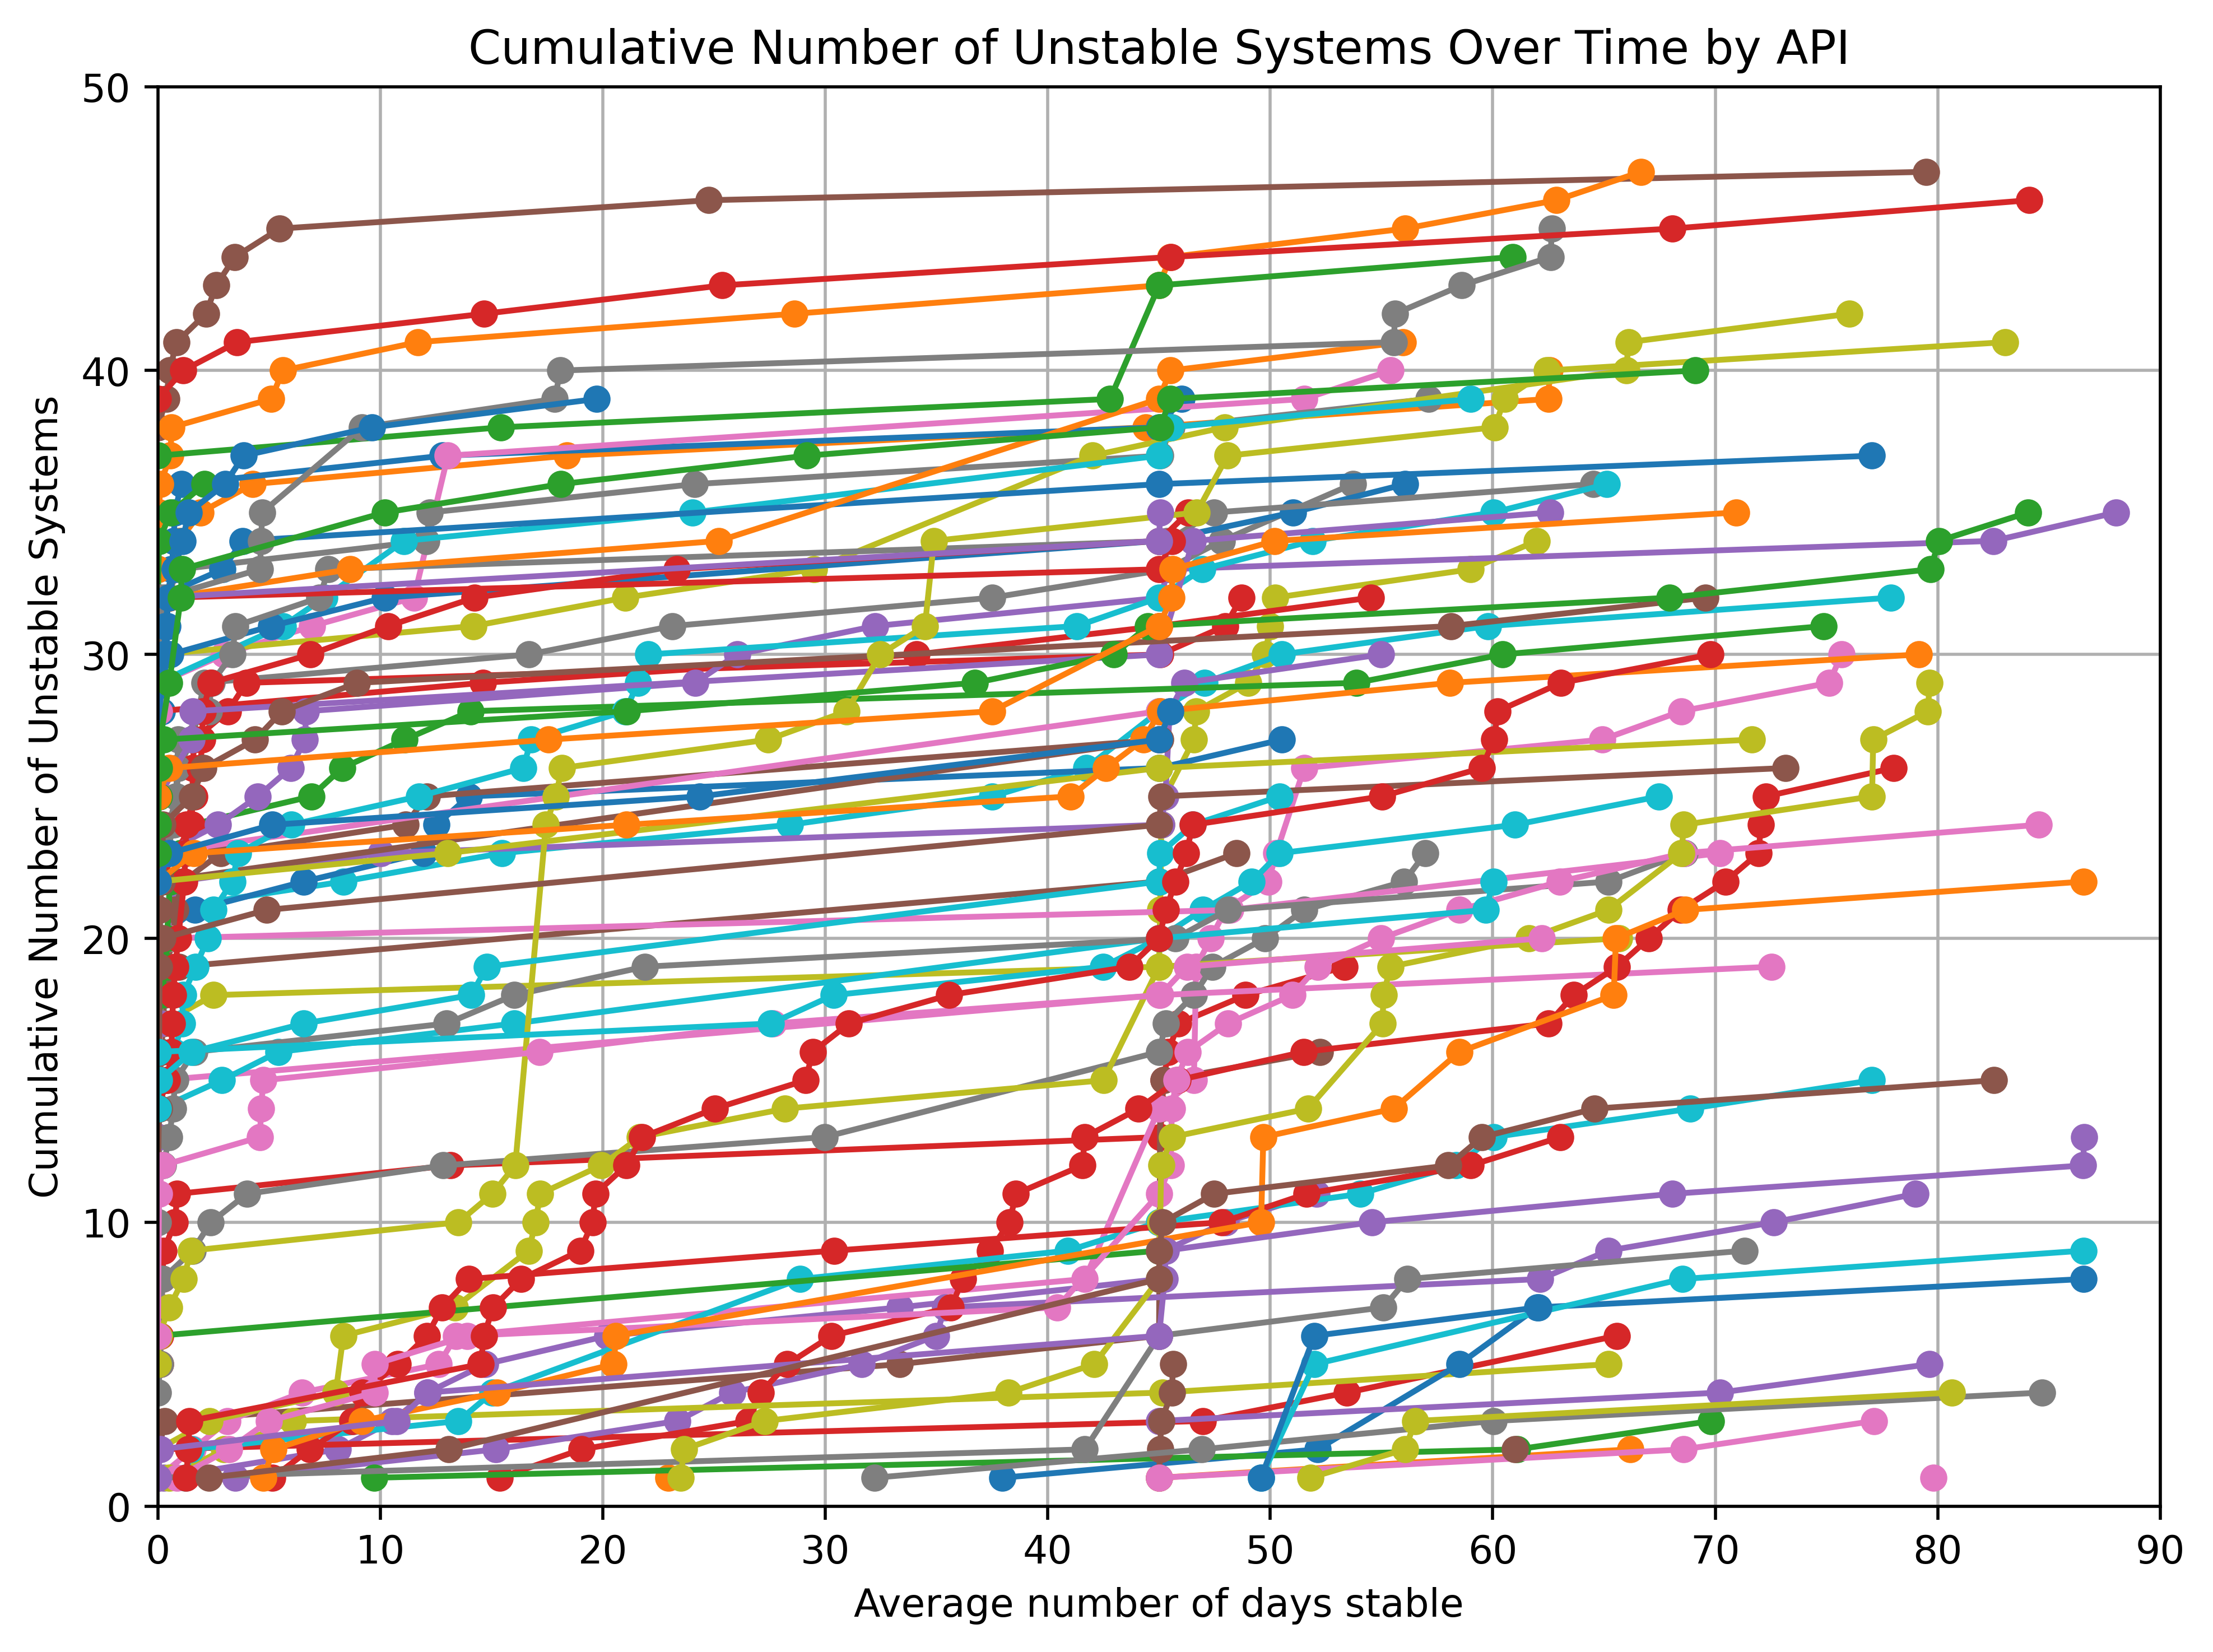

In [57]:
#cumulative line plot (not grouped by condition)
import pandas as pd 
import matplotlib.pyplot as plt
import os

save_dir = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Plots'

#Define a threshold for instability
stability_threshold = 90

#Determine unstable systems
df['Unstable'] = df['days stable'] < stability_threshold

#Set up the figure size and resolution
plt.figure(figsize=(8, 6), dpi=500)

grouped_line = df.groupby(['API', 'condition'])

#Group data by API and plot each
for (api, condition), group in grouped_line: # Group by 'days stable' and count unstable systems 

    unstable_counts = group[group['Unstable']].groupby('days stable')['Unstable'].count().cumsum()
    plt.plot(unstable_counts.index, unstable_counts.values, marker='o', linestyle='-', label=f'API: {api}')
    
#Add labels and title
plt.xlim(0,90)
plt.ylim(0,50)
plt.xticks(np.arange(0, 91, step=10))
plt.xlabel('Average number of days stable') 
plt.ylabel('Cumulative Number of Unstable Systems') 
plt.title('Cumulative Number of Unstable Systems Over Time by API') 
#plt.legend(title=f'API @ {condition}', ncol=2, loc='upper left', borderaxespad=0.)
plt.grid(True)

#Show the plot
plt.tight_layout() 
plot_filename = os.path.join(save_dir, 'Cumulative Number of Unstable Systems Over Time by API.png')
plt.savefig(plot_filename)
plt.show()

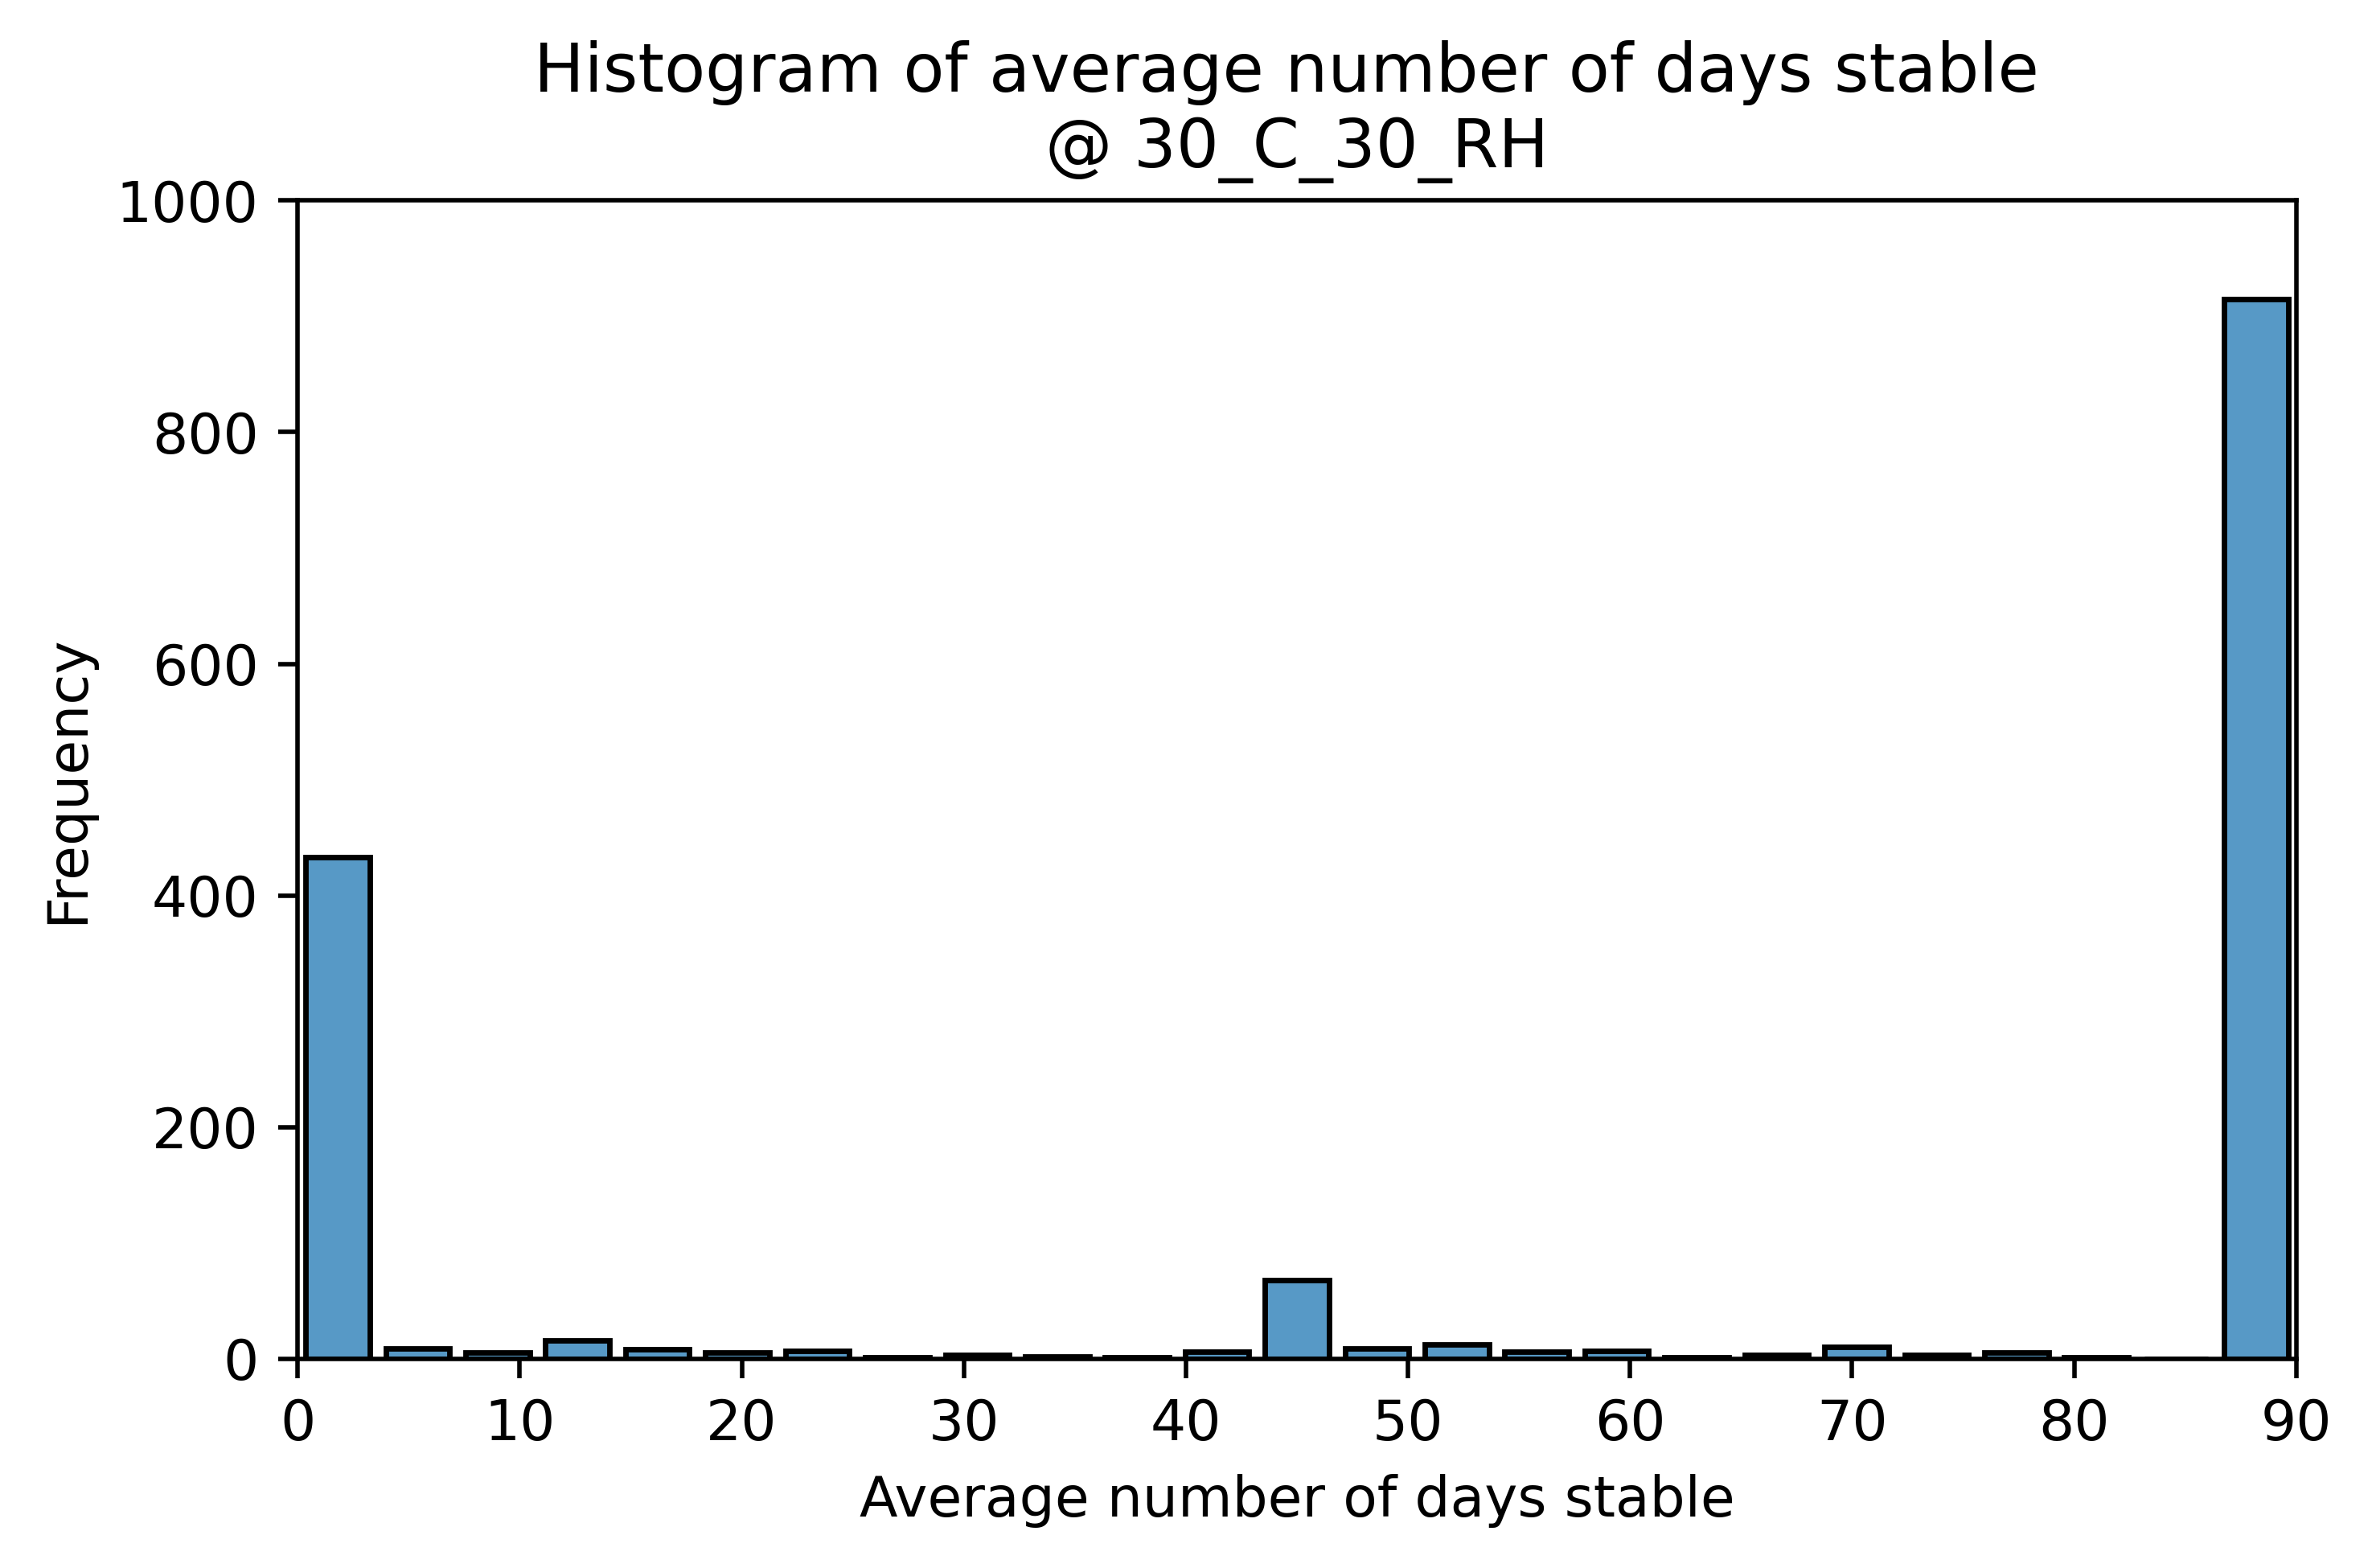

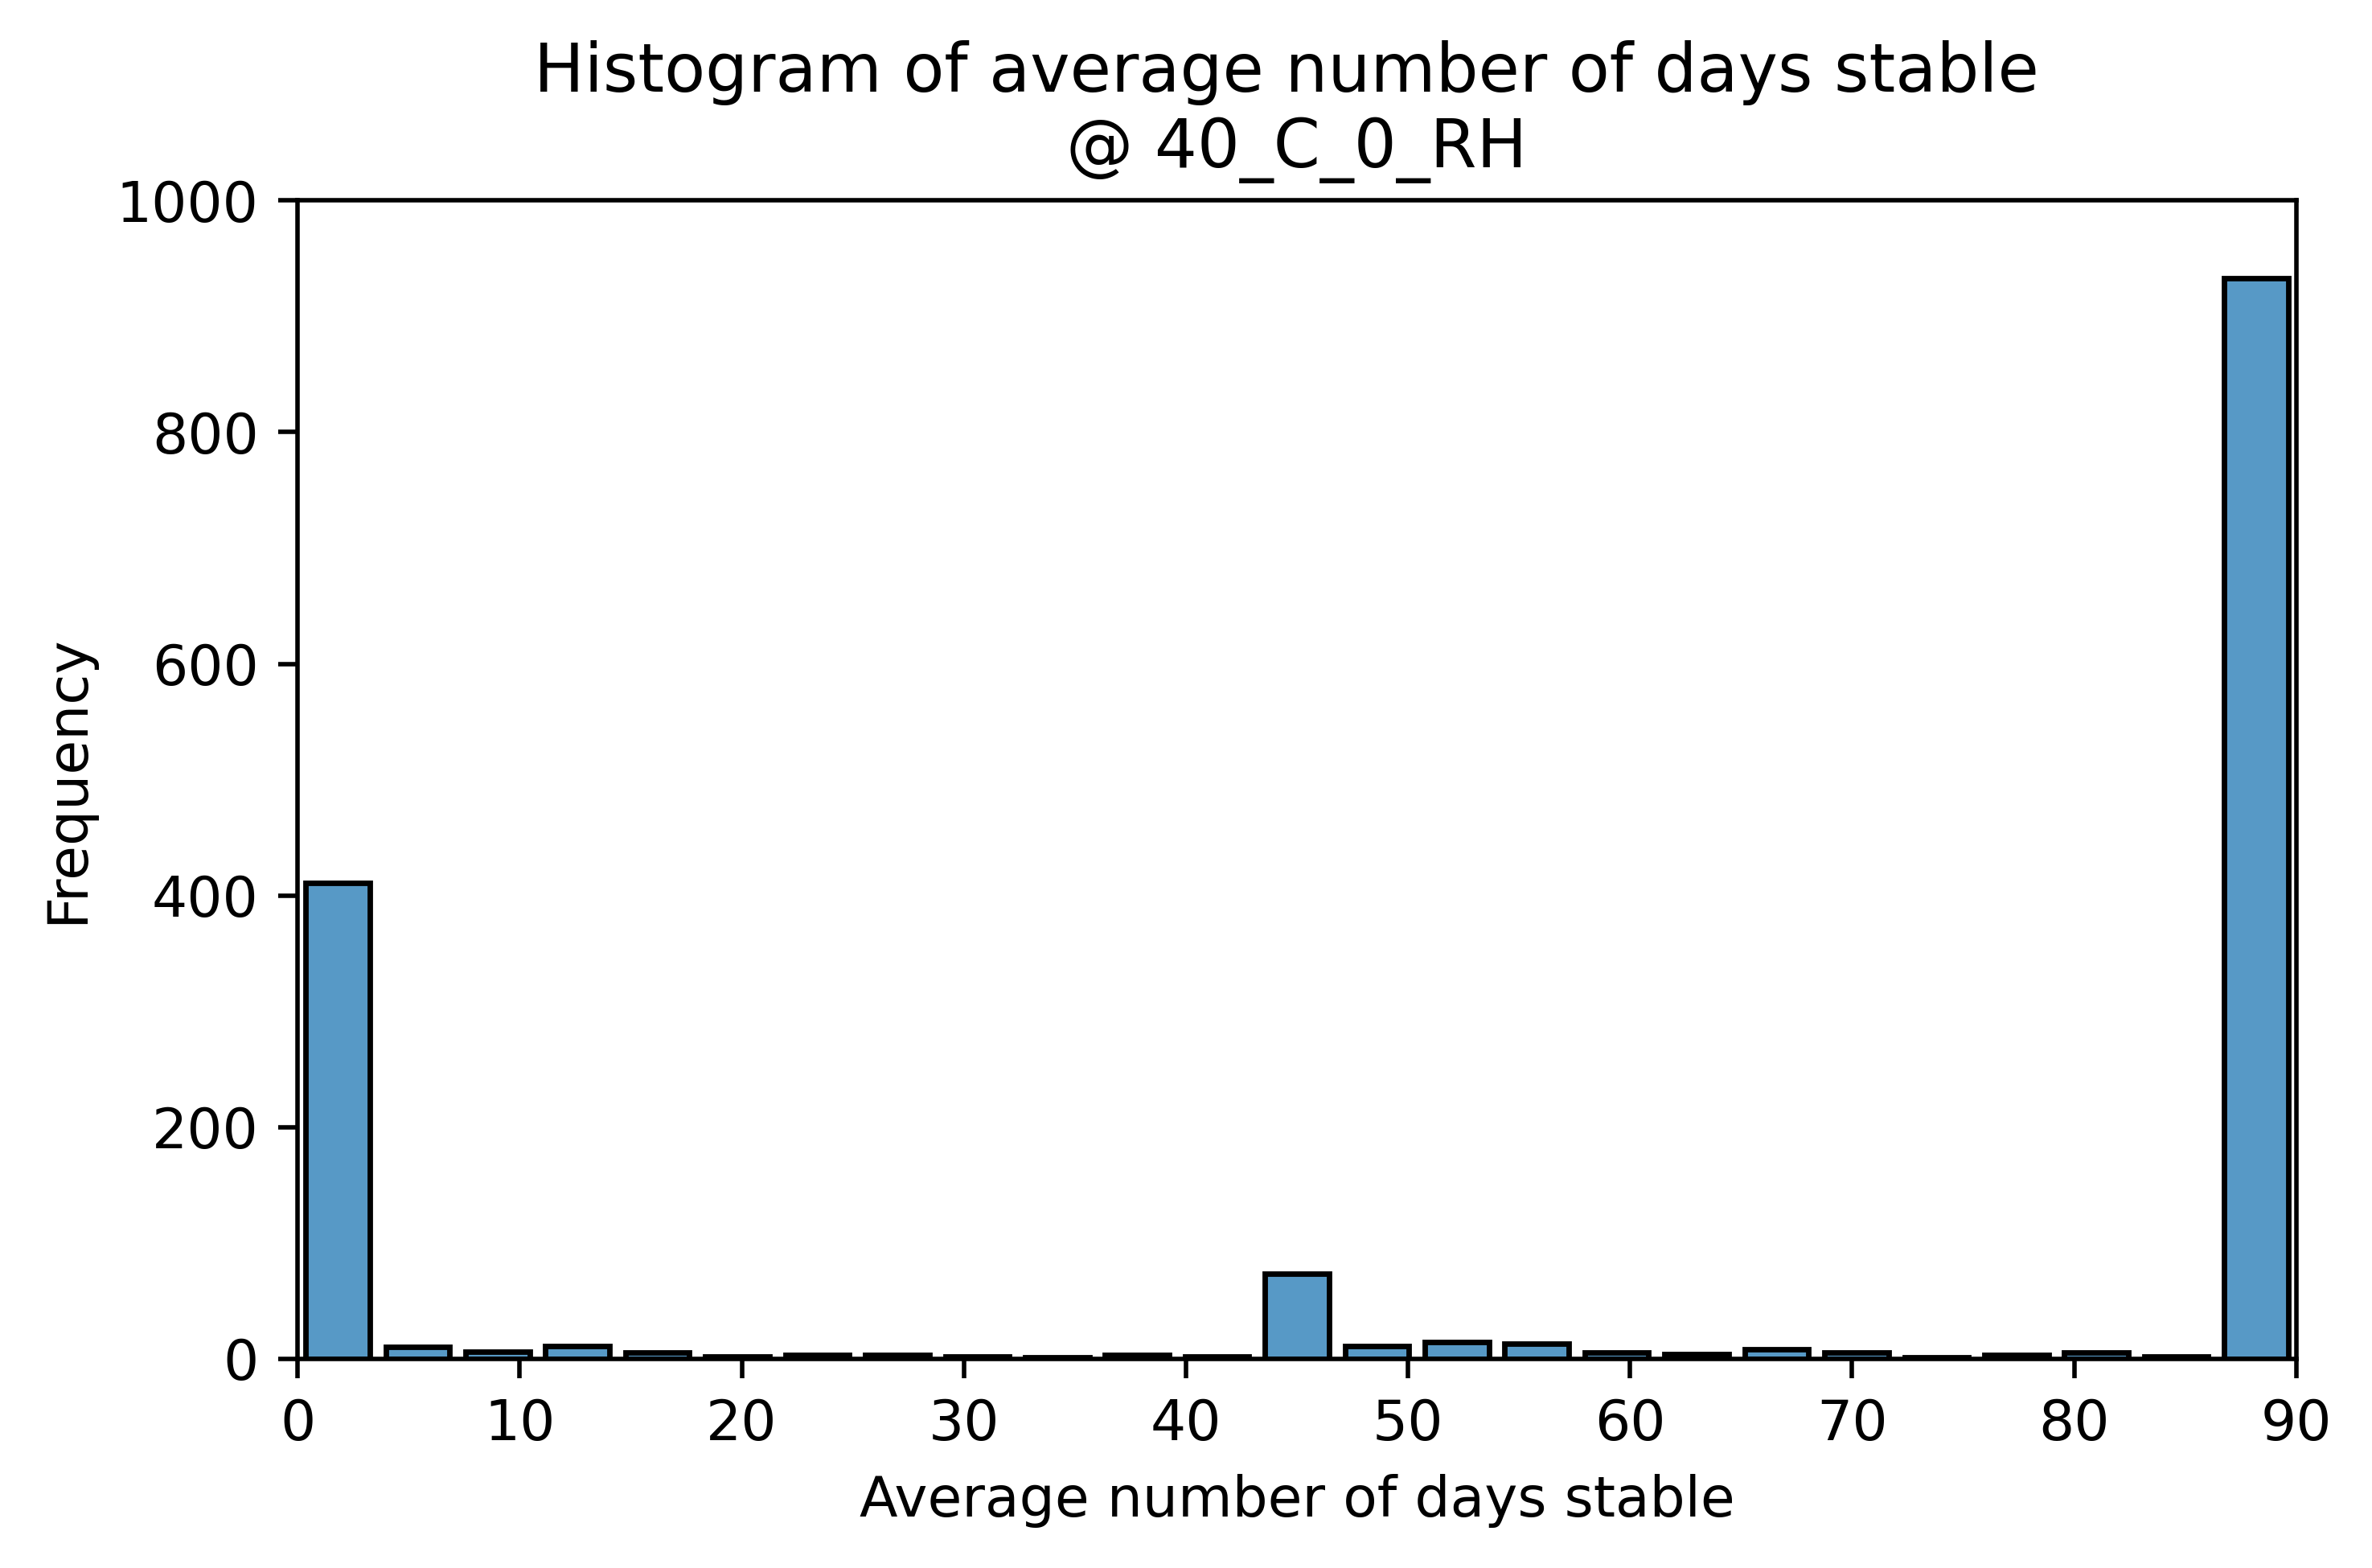

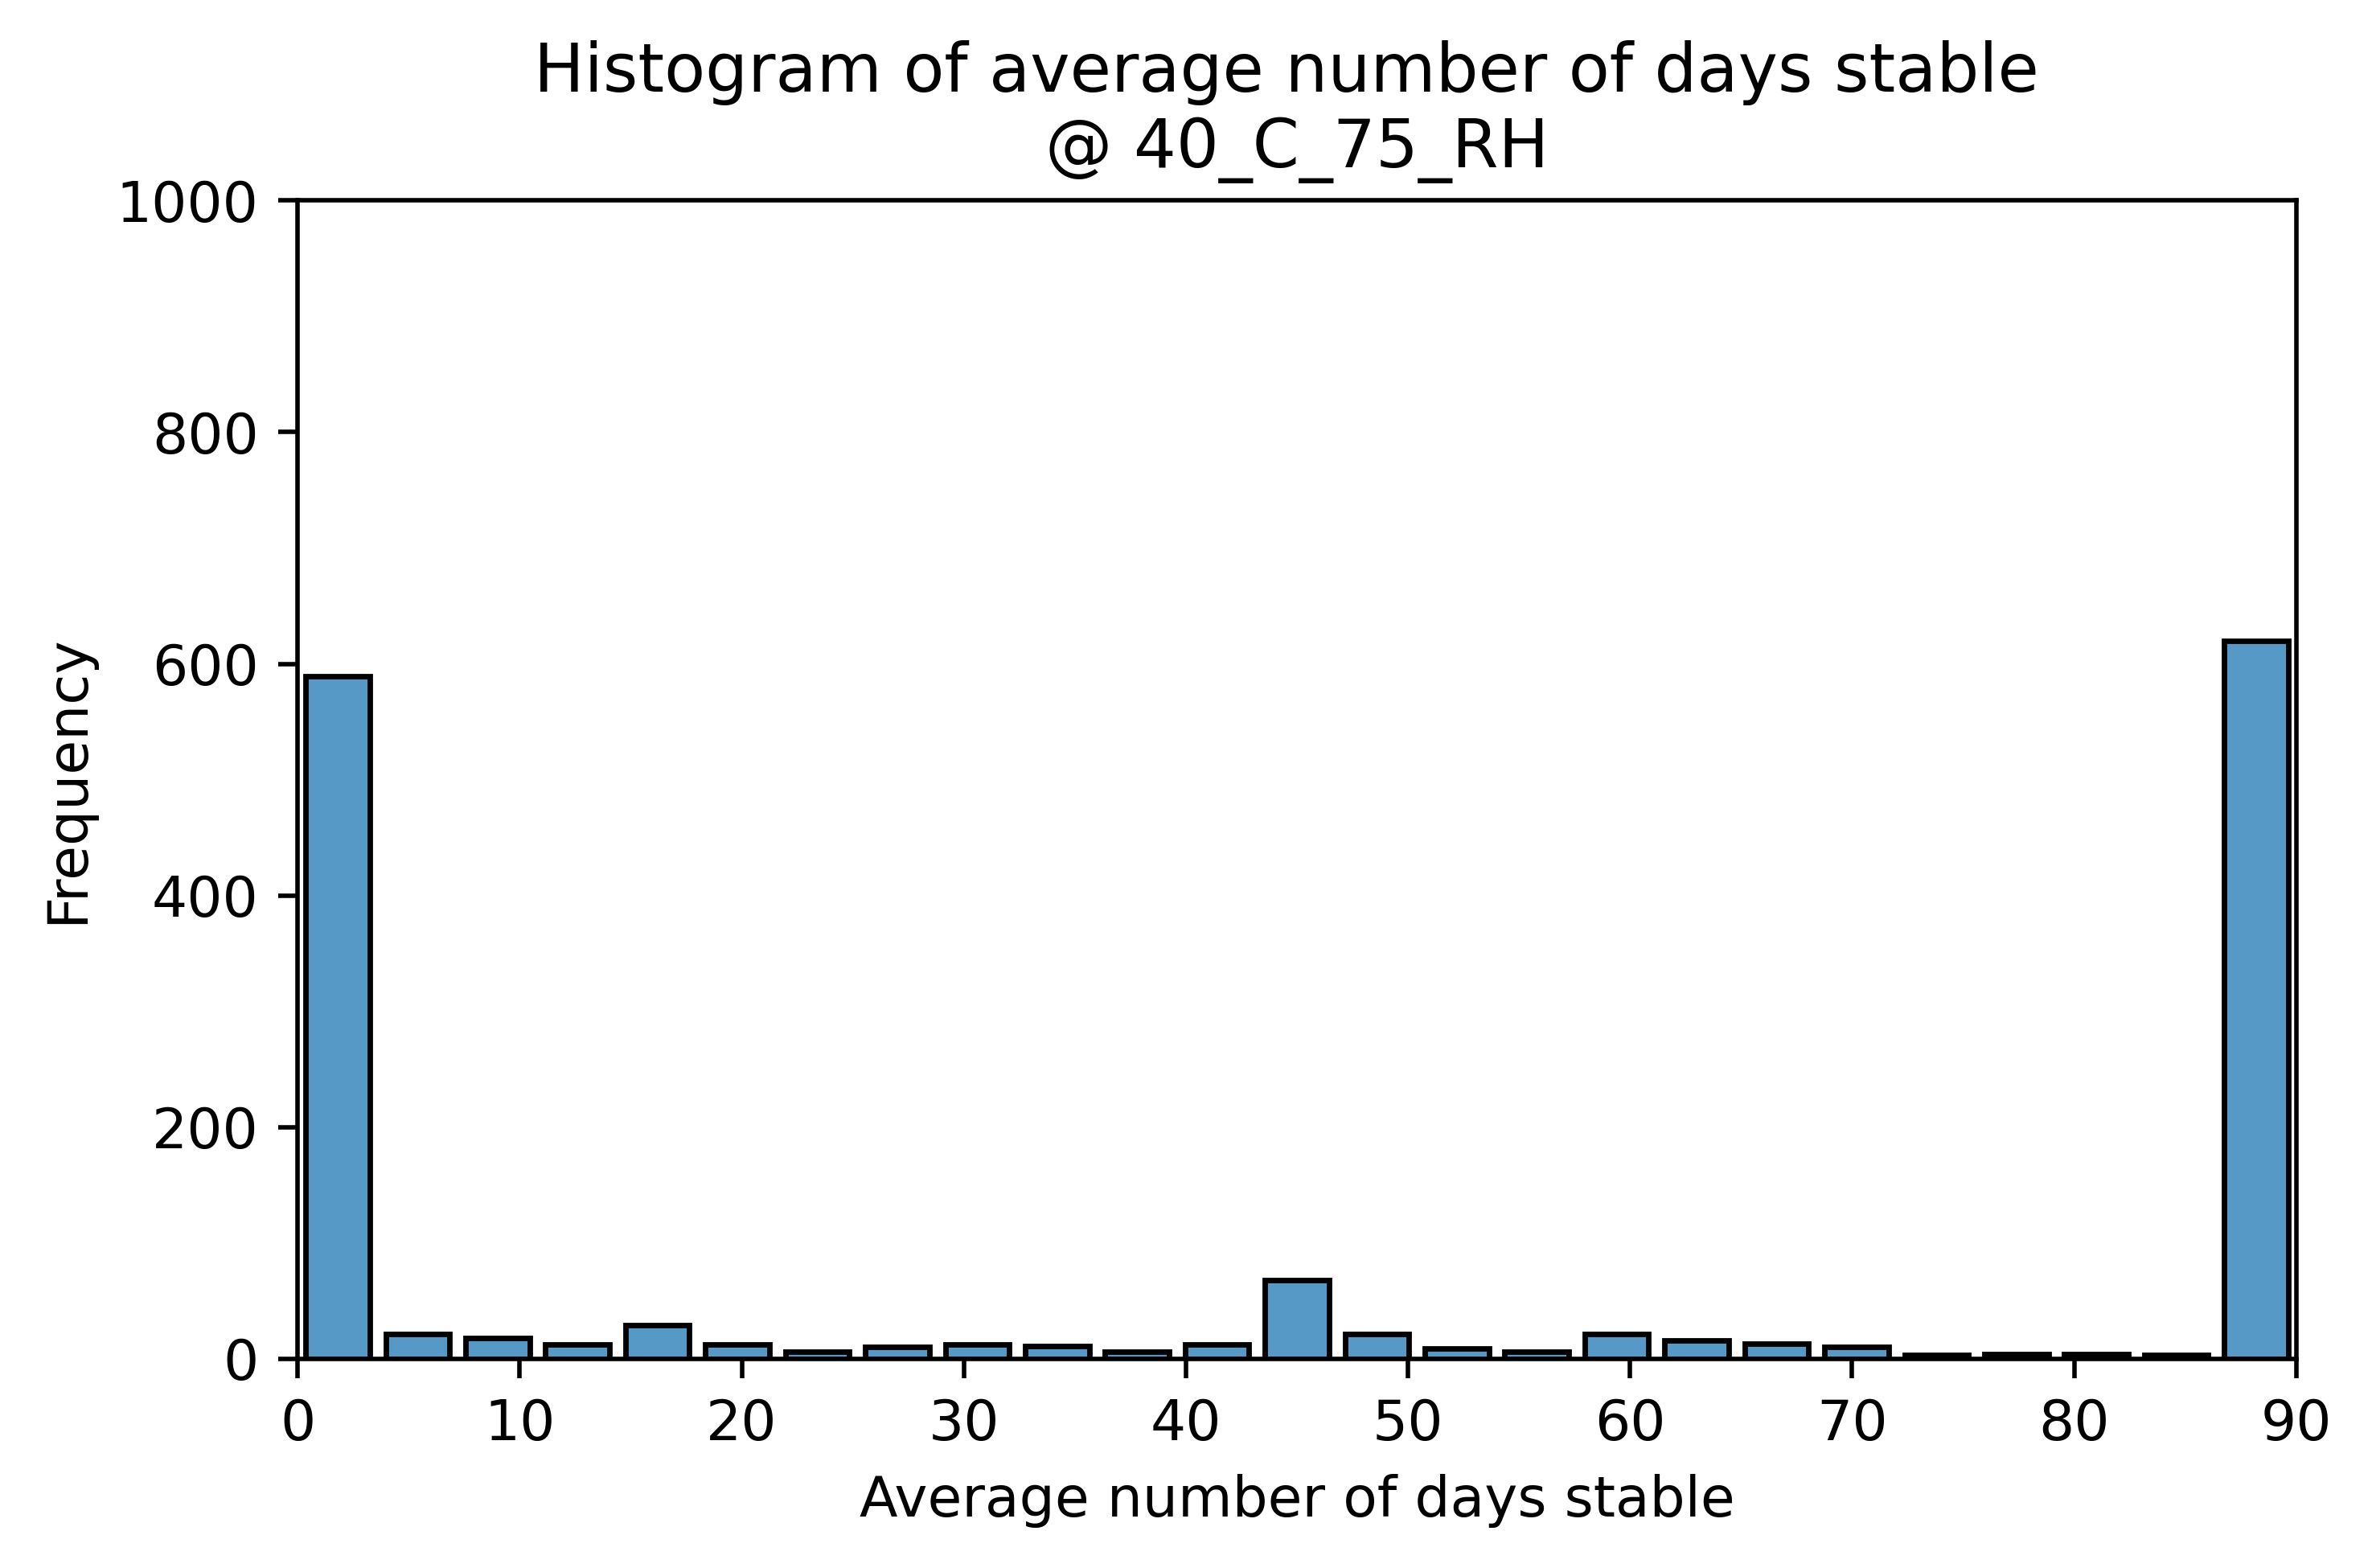

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

save_dir = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Plots'

grouped_data=df.groupby('condition')

# Plot histograms for each condition
for condition, group in grouped_data:
    # Use the 'days stable' directly from the group
    
    plt.figure(figsize=(6, 4), dpi=500)

    sns.histplot(
        data= group, 
        x= 'days stable',
        bins = 25, #
        shrink = 0.8,
        edgecolor = 'black'
    )
    plt.xticks(np.arange(0, 91, step = 10))
    plt.ylim(0,1000)
    plt.xlim(0, 90)
    plt.xlabel('Average number of days stable')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of average number of days stable \n@ {condition}')
    #plt.grid(True)

    # Show the plot for each condition independently
    plt.tight_layout()
    plot_filename = os.path.join(save_dir, f'Histogram of Average Days Stable at {condition}')
    plt.savefig(plot_filename)
    plt.show()

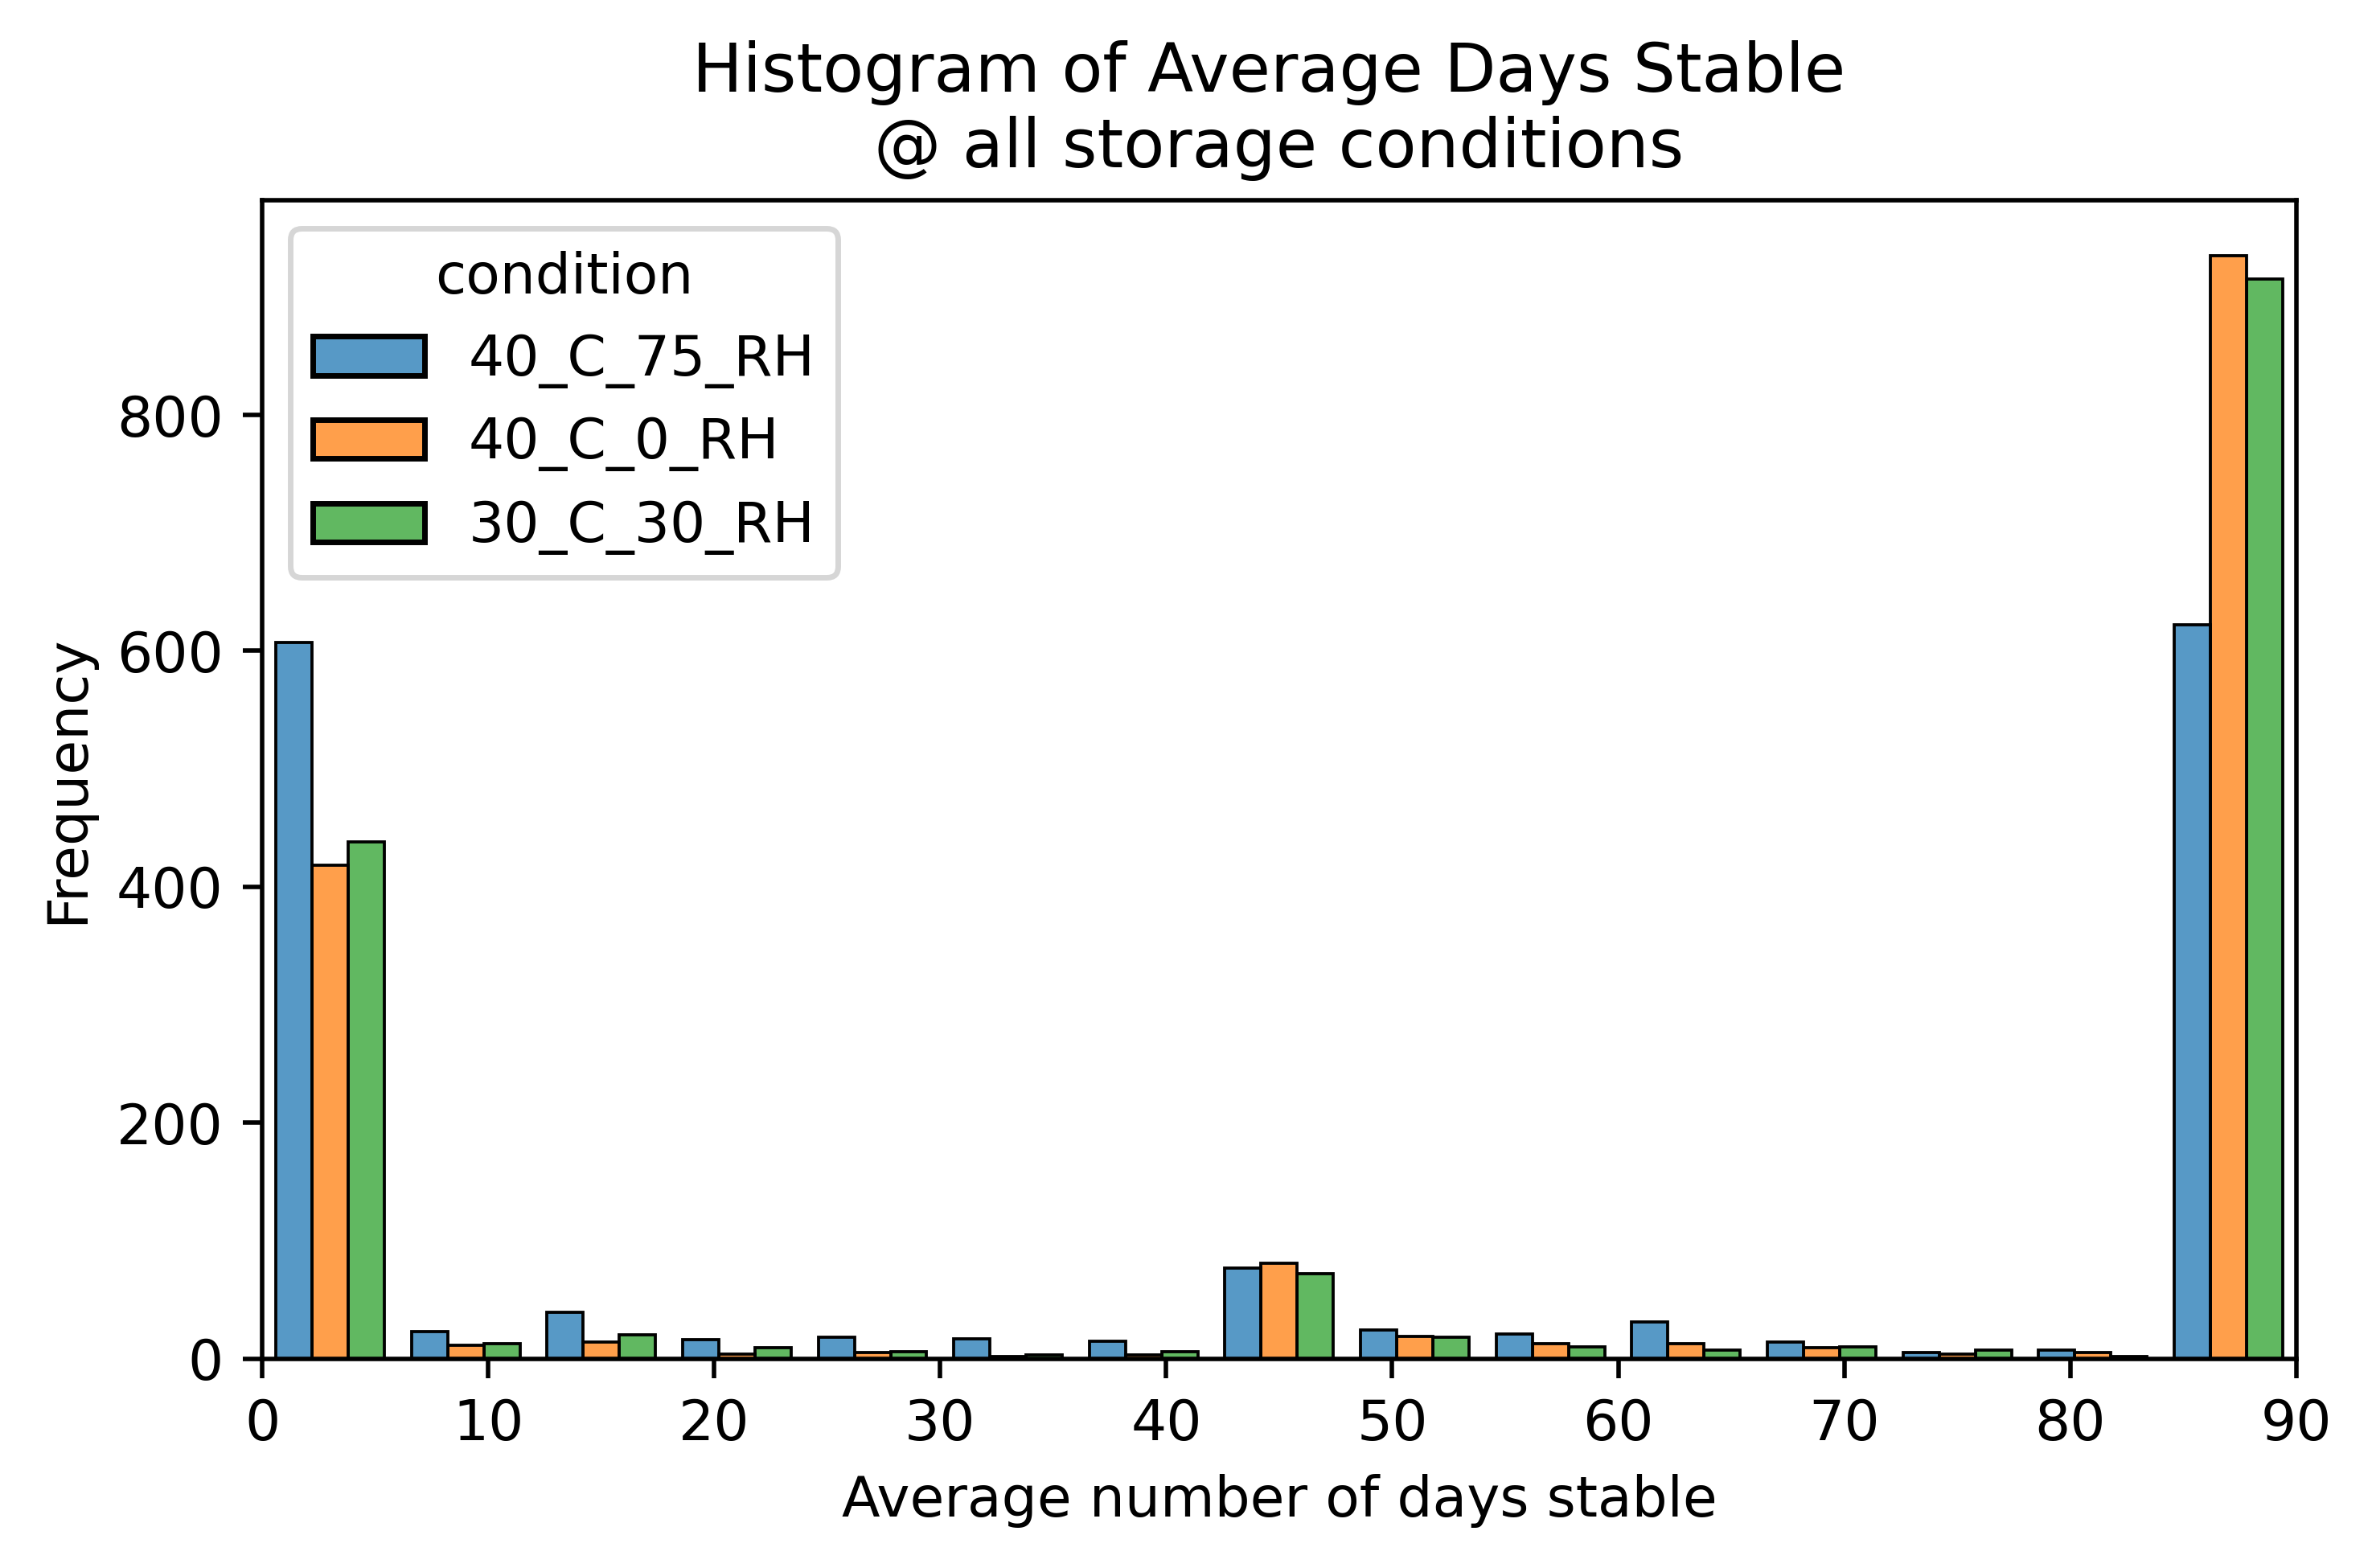

In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

save_dir = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Plots'

plt.figure(figsize=(6,4), dpi=500)

ax = sns.histplot(
    data=df,
    x = 'days stable', 
    hue = 'condition', 
    hue_order=['40_C_75_RH', '40_C_0_RH', '30_C_30_RH'],
    bins = 15,
    multiple= 'dodge',
    shrink = 0.8, 
    edgecolor = 'black'
)


#ax.patches[0].set_facecolor('red')
#ax.patches[25].set_facecolor('red')
#ax.patches[50].set_facecolor('red')
    
# Add labels and title
plt.xlabel('Average number of days stable')
plt.ylabel('Frequency')
plt.title('Histogram of Average Days Stable \n@ all storage conditions')
plt.xticks(np.arange(0, 91, step=10))
plt.xlim(0, 90)

# Show the plot
plt.tight_layout()
plot_filename = os.path.join(save_dir, 'Histogram of Average Days Stable at all storage conditions')
plt.savefig(plot_filename)
plt.show()

   Number of unstable systems  Number of stable systems  \
0                        2146                      2462   

   Percentage of stable systems  Percentage of unstable systems  
0                     53.428819                       46.571181  


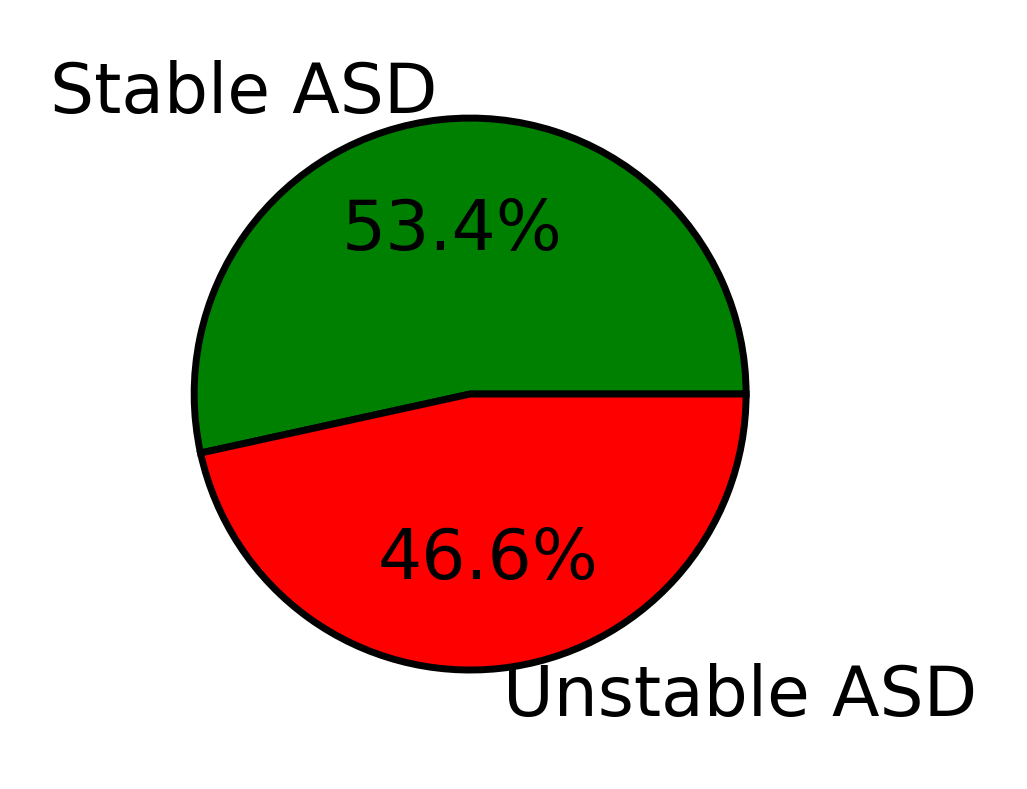

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['binary_stability']= (df['Average days stable']<2160).astype(int)
unstable_count = df['binary_stability'].sum()
stable_count = (df['binary_stability'] ==0).sum()
total=len(df)

model_bias_df = pd.DataFrame([{
    'Number of unstable systems': unstable_count,
    'Number of stable systems': stable_count,
    'Percentage of stable systems': (stable_count/total)*100,
    'Percentage of unstable systems':(unstable_count/total)*100
}])

print(model_bias_df)

plt.figure(figsize=(2,3), dpi=500)
sizes = [stable_count, unstable_count]
labels = ['Stable ASD', 'Unstable ASD']
colors = ['green', 'red']

plt.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct='%.1f%%',
    wedgeprops={'edgecolor': 'black'}
)
#plt.title('Stable vs unstable ASDs')
plt.tight_layout()
plt.show()


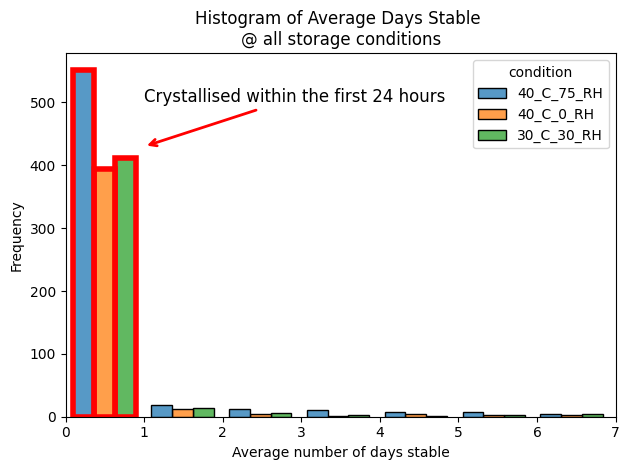

In [179]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_one_week_cryst = df[(df['Average days stable'])<168]
df_one_week_cryst

ax = sns.histplot(
    data=df_one_week_cryst,
    x = 'days stable', 
    hue = 'condition',
    hue_order=['40_C_75_RH', '40_C_0_RH', '30_C_30_RH'],
    bins = 7,
    multiple= 'dodge',
    shrink = 0.8, 
    edgecolor = 'black'
)


ax.patches[0].set_edgecolor('red')
ax.patches[0].set_linewidth(4)
ax.patches[7].set_edgecolor('red')
ax.patches[7].set_linewidth(4)
ax.patches[14].set_edgecolor('red')
ax.patches[14].set_linewidth(4)


# Add labels and title
plt.xlabel('Average number of days stable')
plt.ylabel('Frequency')
plt.title('Histogram of Average Days Stable \n@ all storage conditions')
plt.xticks(np.arange(0, 8, step=1))
plt.xlim(0, 7)
#plt.text(x=1.5, y=450, s='red - crystallised \nwithin the first day', fontsize=12, color='black')
plt.annotate('Crystallised within the first 24 hours', 
             xy=(1, 430), 
             xycoords = 'data', 
             xytext = (1, 500),
             textcoords = 'data',
             arrowprops=dict(arrowstyle="->", color="red", lw=2),
             fontsize=12,
             color='black')



# Show the plot
plt.tight_layout()
plot_filename = os.path.join(save_dir, 'Histogram of first weeks stability at all storage conditions')
plt.savefig(plot_filename)
plt.show()